# MACH 01 · Colour–magnitude diagram and red sequence

1. Fit the red sequence (median (g − r) vs. M_r of the spectroscopic members within R200) with a linear MCMC fit.
2. Predict Dn4000 from (g − r) by linear regression (used later to split photometric galaxies into quiescent / star-forming).
3. Per cluster, the fraction of spectroscopic galaxies that are members above, on and below the red sequence (contamination check, Figure 5).

**Inputs** (not included): `DATA/MACH_PHOT/MACH_photcat_3R200.csv`, `DATA/MACH_PHOT/AllHeCS_VAC_updated.csv`, `../SMF/MACH_1dspec_limit.csv`

**Output**: `FIGURE/IMAGES/Figure5.pdf`

In [5]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [6]:
# Define file paths
mach_file = f"{MAINPATH}/DATA/MACH_PHOT/MACH_photcat_3R200.csv"
hecs_vac_file = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"

# Load datasets
mach_data = pd.read_csv(mach_file)
hecs_vac_data = pd.read_csv(hecs_vac_file)

# Apply extinction corrections to cmodelMag and modelMag columns
mach_data['cmodelMag_r_0'] = mach_data['cmodelMag_r'] - mach_data['extinction_r']
mach_data['cmodelMag_g_0'] = mach_data['cmodelMag_g'] - mach_data['extinction_g']

mach_data['modelMag_r_0'] = mach_data['modelMag_r'] - mach_data['extinction_r']
mach_data['modelMag_g_0'] = mach_data['modelMag_g'] - mach_data['extinction_g']

# Objects within 3 R200
df = mach_data.loc[mach_data['Rcl/R200'] <= 3.0].copy()

# Calculate absolute r-band magnitude using extinction-corrected apparent magnitude and luminosity distance
df['AbsMag_r'] = (
    df['cmodelMag_r_0']
    - 5 * np.log10(cosmo.luminosity_distance(df['Z_TOT_Z']).to('pc').value / 10)
)

/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/astropy/cosmology/flrw/lambdacdm.py:397: RuntimeWarning: invalid value encountered in sqrt
  return 2 * np.sqrt(x) * hyp2f1(1.0 / 6, 1.0 / 2, 7.0 / 6, -(x**3))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72773/1289144891.py:22: RuntimeWarning: divide by zero encountered in log10
  - 5 * np.log10(cosmo.luminosity_distance(df['Z_TOT_Z']).to('pc').value / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72773/1289144891.py:22: RuntimeWarning: invalid value encountered in log10
  - 5 * np.log10(cosmo.luminosity_distance(df['Z_TOT_Z']).to('pc').value / 10)


# 1. Red sequence of the stacked members

Running MCMC...


100%|██████████| 5000/5000 [00:02<00:00, 2468.15it/s]



MCMC Linear Fit Results:
  Slope     = -0.036 ± 0.001
  Intercept = 0.124 ± 0.030


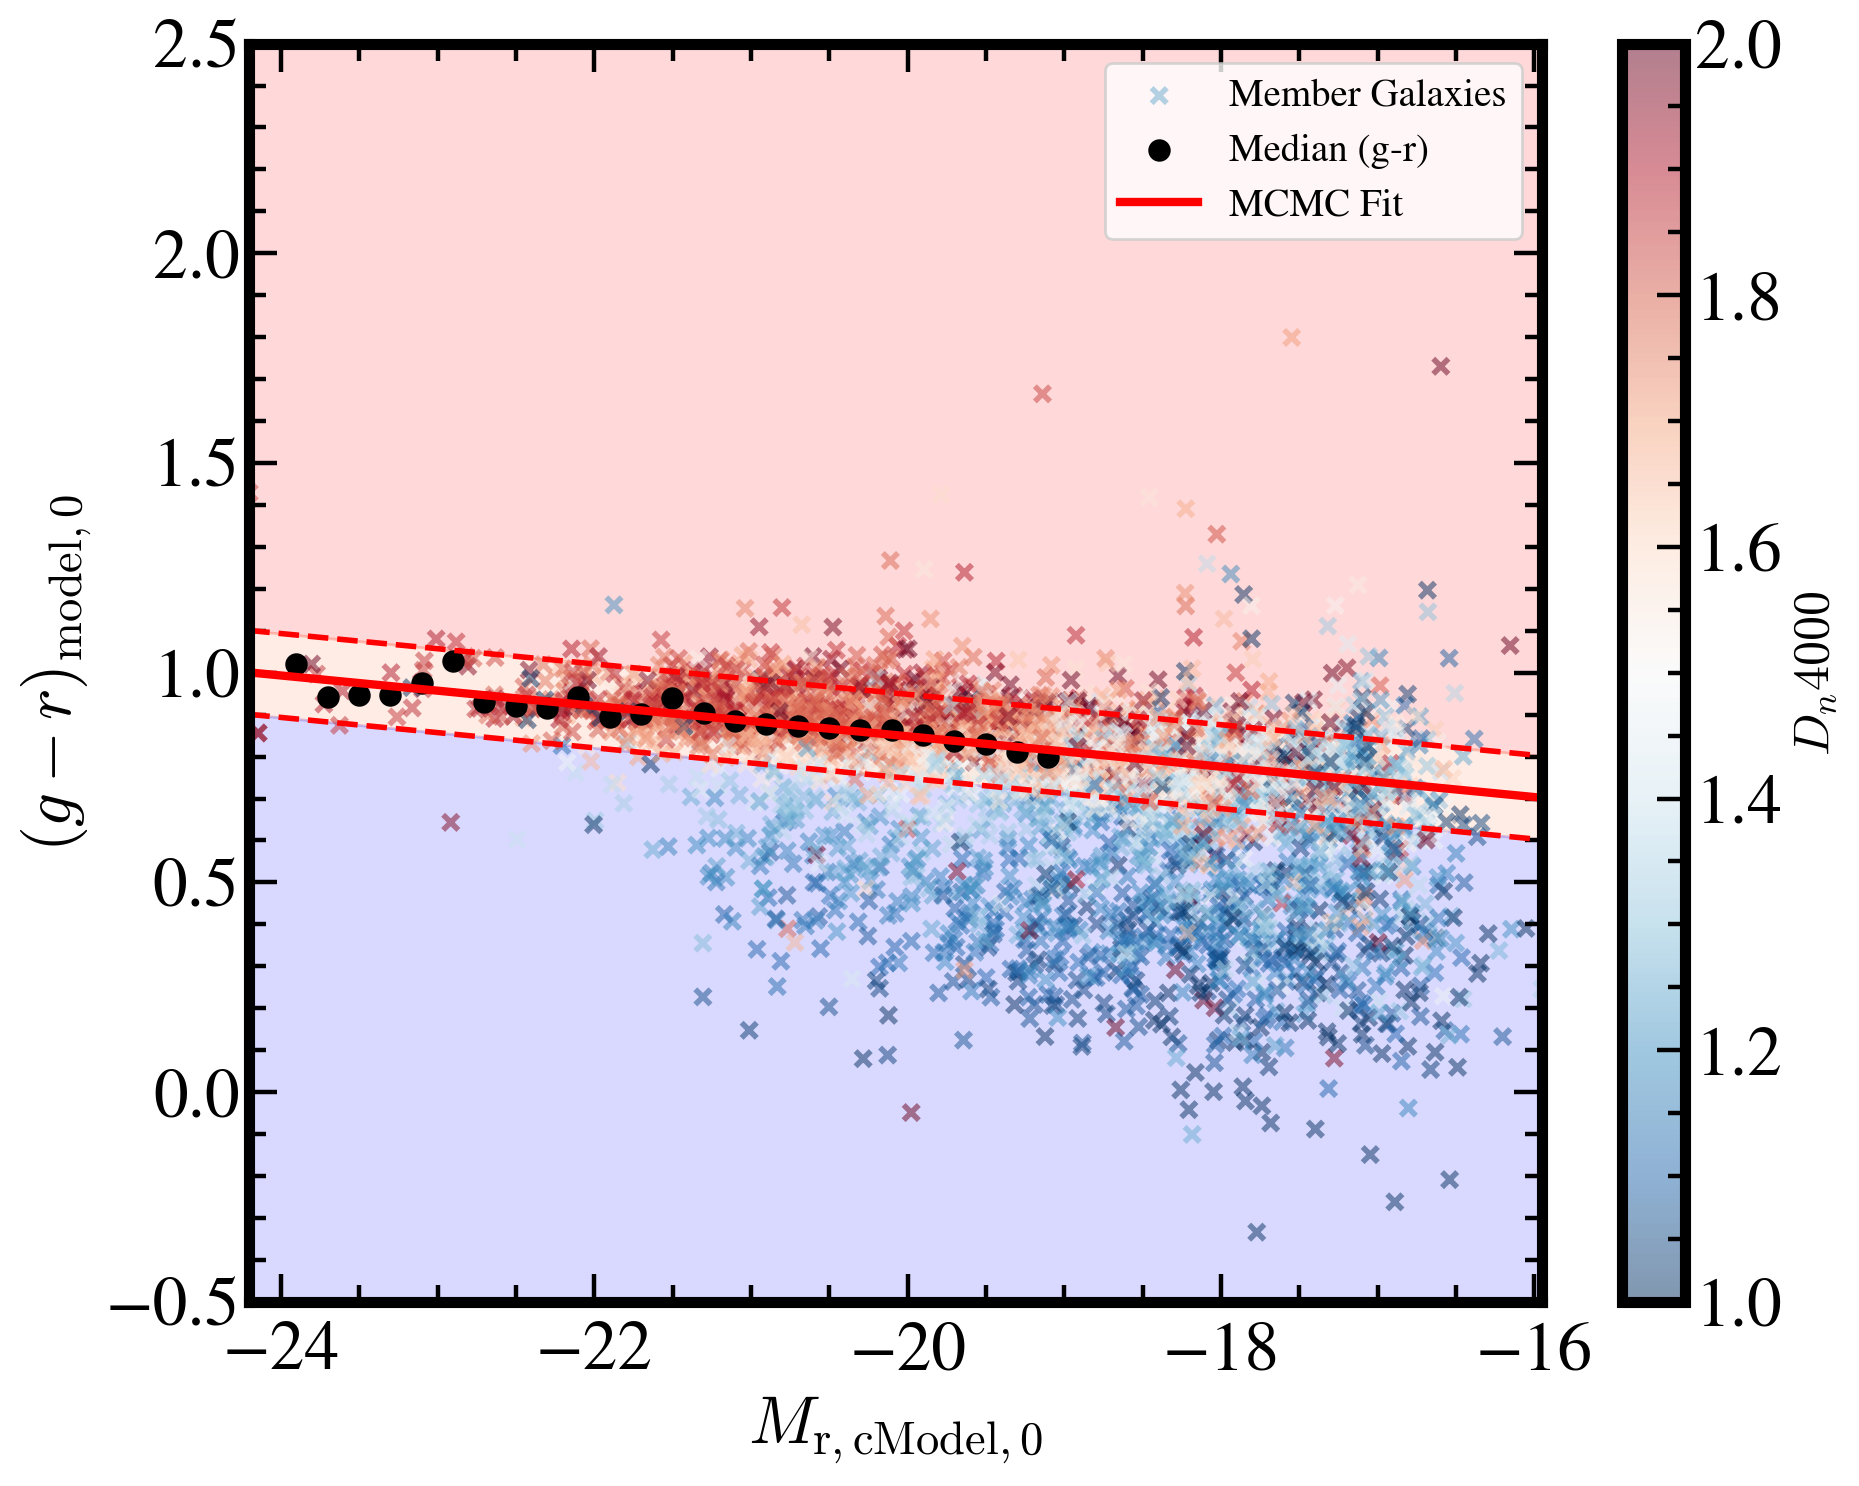

Number of galaxies above upper envelope: 384
Number of galaxies between envelopes: 2462
Number of galaxies below lower envelope: 1191


In [7]:
import emcee

# 1. Filter for cluster members within R200 and valid redshift
filtered_df_member = df[
    (df['Rcl/R200'] <= 1.0) &
    (df['Z_TOT_Z'] != -99) &
    (df['MEMBER'] == 'Y')
]

# 2. Bin AbsMag_r, calculate median (g - r) color in bins
bin_width = 0.2
abs_mag_bins = np.arange(
    filtered_df_member['AbsMag_r'].min(),
    filtered_df_member['AbsMag_r'].max() + bin_width,
    bin_width
)

bin_centers, median_g_r = [], []
for i in range(len(abs_mag_bins) - 1):
    this_bin = (filtered_df_member['AbsMag_r'] >= abs_mag_bins[i]) & (filtered_df_member['AbsMag_r'] < abs_mag_bins[i + 1])
    bin_data = filtered_df_member[this_bin]
    this_center = (abs_mag_bins[i] + abs_mag_bins[i + 1]) / 2
    if len(bin_data) > 0 and (-24 <= this_center <= -19):
        bin_centers.append(this_center)
        median_g_r.append(np.median(bin_data['modelMag_g_0'] - bin_data['modelMag_r_0']))
bin_centers = np.array(bin_centers)
median_g_r = np.array(median_g_r)

# 3. Fit median (g - r) CMD with MCMC: y = m*x + b
def linear_model(theta, x):
    m, b = theta
    return m * x + b

def lnlike(theta, x, y):
    sigma2 = 0.01 ** 2
    model_y = linear_model(theta, x)
    return -0.5 * np.sum((y - model_y) ** 2 / sigma2 + np.log(2 * np.pi * sigma2))

def lnprior(theta):
    m, b = theta
    if -5.0 < m < 5.0 and -5.0 < b < 5.0:
        return 0.0
    return -np.inf

def lnprob(theta, x, y):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y)

ndim, nwalkers = 2, 32
p0 = np.array([0.0, 1.0]) + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(bin_centers, median_g_r))
print("Running MCMC...")
sampler.run_mcmc(p0, 5000, progress=True)

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)
m_mcmc, b_mcmc = np.percentile(flat_samples, 50, axis=0)
m_err = np.std(flat_samples[:, 0])
b_err = np.std(flat_samples[:, 1])

print("\nMCMC Linear Fit Results:")
print(f"  Slope     = {m_mcmc:.3f} ± {m_err:.3f}")
print(f"  Intercept = {b_mcmc:.3f} ± {b_err:.3f}")

# 4. Plot CMD: all galaxies, medians, fit line, envelopes
x_fit = np.linspace(filtered_df_member['AbsMag_r'].min(), filtered_df_member['AbsMag_r'].max(), 100)
y_fit = m_mcmc * x_fit + b_mcmc

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    filtered_df_member['AbsMag_r'],
    filtered_df_member['modelMag_g_0'] - filtered_df_member['modelMag_r_0'],
    s=30,
    c=filtered_df_member['Z_TOT_DN4000'],
    cmap='RdBu_r',
    norm=plt.Normalize(vmin=0, vmax=3),
    marker='x',
    alpha=0.5,
    label='Member Galaxies'
)

ax.scatter(
    bin_centers, median_g_r,
    color='black', s=50, marker='o', zorder=2, label='Median (g-r)'
)

ax.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=3, label='MCMC Fit')

# ±0.1 envelope
ax.plot(x_fit, y_fit + 0.1, 'r--', linewidth=2)
ax.plot(x_fit, y_fit - 0.1, 'r--', linewidth=2)

ax.fill_between(x_fit, y_fit + 0.1, 2.5, color='red', alpha=0.15, zorder=0)
ax.fill_between(x_fit, y_fit - 0.1, y_fit + 0.1, color='orangered', alpha=0.1, zorder=0)
ax.fill_between(x_fit, -0.5, y_fit - 0.1, color='blue', alpha=0.15, zorder=0)

ax.set_xlim([filtered_df_member['AbsMag_r'].min(), filtered_df_member['AbsMag_r'].max()])
ax.set_ylim([-0.5, 2.5])
ax.set_xlabel(r'$M_\mathrm{r, cModel, 0}$', fontsize=24)
ax.set_ylabel(r'$(g-r)_\mathrm{model,0}$', fontsize=24)
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.minorticks_on()
ax.legend(fontsize=14)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$D_n4000$', fontsize=18)
cbar.mappable.set_clim(1, 2)

plt.tight_layout()
plt.show()

# 5. Count galaxies in CMD regions defined by fit and ±0.1 envelope
g_r_color = filtered_df_member['modelMag_g_0'] - filtered_df_member['modelMag_r_0']
linear_fit = m_mcmc * filtered_df_member['AbsMag_r'] + b_mcmc
upper_env = linear_fit + 0.1
lower_env = linear_fit - 0.1

above_upper = np.sum(g_r_color > upper_env)
below_lower = np.sum(g_r_color < lower_env)
between = np.sum((g_r_color >= lower_env) & (g_r_color <= upper_env))

print(f'Number of galaxies above upper envelope: {above_upper}')
print(f'Number of galaxies between envelopes: {between}')
print(f'Number of galaxies below lower envelope: {below_lower}')

# 2. Dn4000 predicted from (g − r)

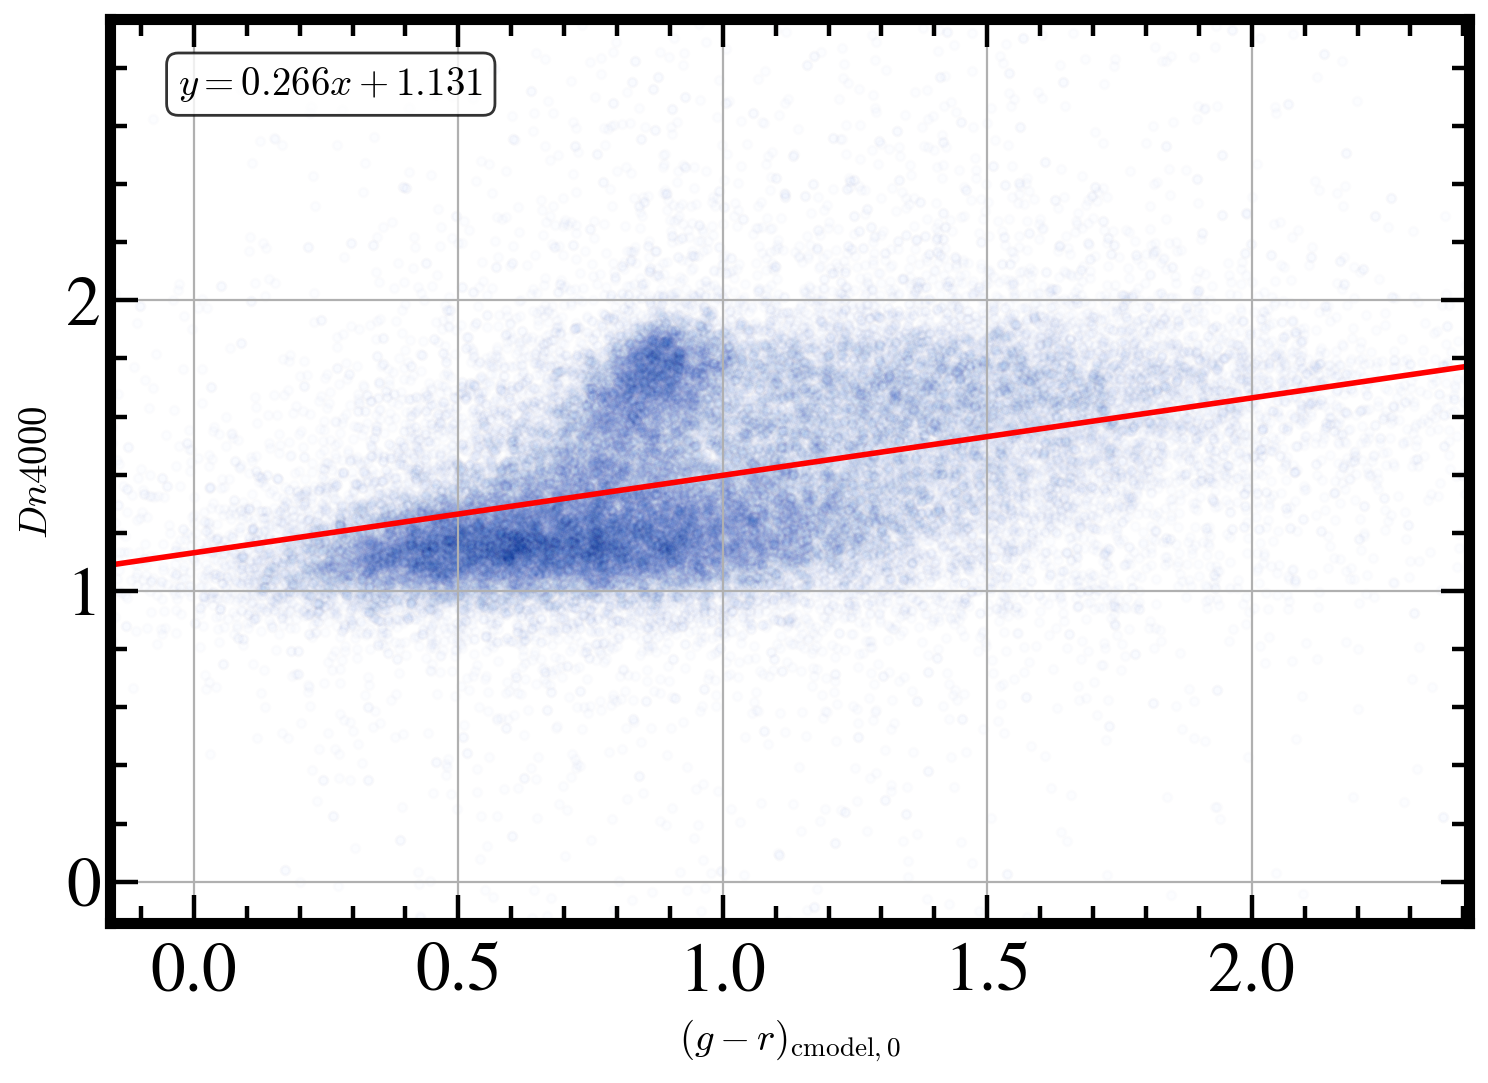

In [8]:
# Dn4000 vs (g-r) scatter + linear fit

from sklearn.linear_model import LinearRegression

# 1. Filter MACH data for good Dn4000 measurements (remove NaN, -99, and extreme outliers)
cmd_df = mach_data[
    (mach_data['Z_TOT_DN4000'].notna()) &  # Only valid
    (mach_data['Z_TOT_DN4000'] != -99) &   # Not flagged -99
    (mach_data['Z_TOT_DN4000'].between(-10, 10))  # Remove extreme outliers
].copy()

# 2. Compute (g - r) color with cModel magnitudes
cmd_df['g_r'] = cmd_df['cmodelMag_g_0'] - cmd_df['cmodelMag_r_0']

# 3. Drop galaxies with ridiculous (g-r) color (< -100)
cmd_df = cmd_df[cmd_df['g_r'] > -100]

# 4. (Optional) Further restrict Dn4000 to range -5 <= Dn4000 <= 5
cmd_df = cmd_df[cmd_df['Z_TOT_DN4000'].between(-5, 5)]

# 5. Calculate 0.5% and 99.5% percentiles for (g-r) and Dn4000 for plot/fit window
x_q2, x_q98 = cmd_df['g_r'].quantile([0.005, 0.995])
y_q2, y_q98 = cmd_df['Z_TOT_DN4000'].quantile([0.005, 0.995])

# 6. Prepare features/target for regression: predict Dn4000 from color
X = cmd_df[['g_r']].values  # shape (n_samples, 1)
y = cmd_df['Z_TOT_DN4000'].values

# 7. Linear regression: Dn4000 = slope * (g-r) + intercept
model = LinearRegression()
model.fit(X, y)
slope = model.coef_[0]
intercept = model.intercept_

# 8. Generate fit line using percentile range for clean visualization
x_fit = np.linspace(x_q2, x_q98, 500)
y_fit = model.predict(x_fit.reshape(-1, 1))

# 9. Plot Dn4000 vs (g-r) scatter and regression line
fig, ax = plt.subplots(figsize=(8, 6))

scatter_kwargs = {
    's': 10,
    'facecolors': 'dodgerblue',
    'edgecolors': 'darkblue',
    'alpha': 0.01
}
ax.scatter(cmd_df['g_r'], cmd_df['Z_TOT_DN4000'], **scatter_kwargs)
ax.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear fit')

# Annotate fit equation
eq_label = f"$y={slope:.3f}x {intercept:+.3f}$"
ax.text(0.05, 0.95, eq_label, transform=ax.transAxes,
        va='top', fontsize=14,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

# Set axis labels and plot limits
ax.set_xlabel('$(g - r)_\\mathrm{cmodel,0}$', fontsize=14)
ax.set_ylabel('$Dn4000$', fontsize=14)
ax.set_xlim(x_q2, x_q98)
ax.set_ylim(y_q2, y_q98)
ax.grid(True)

plt.tight_layout()
plt.show()

# 3. Member fraction above, on and below the red sequence (Figure 5)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72773/1330372674.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


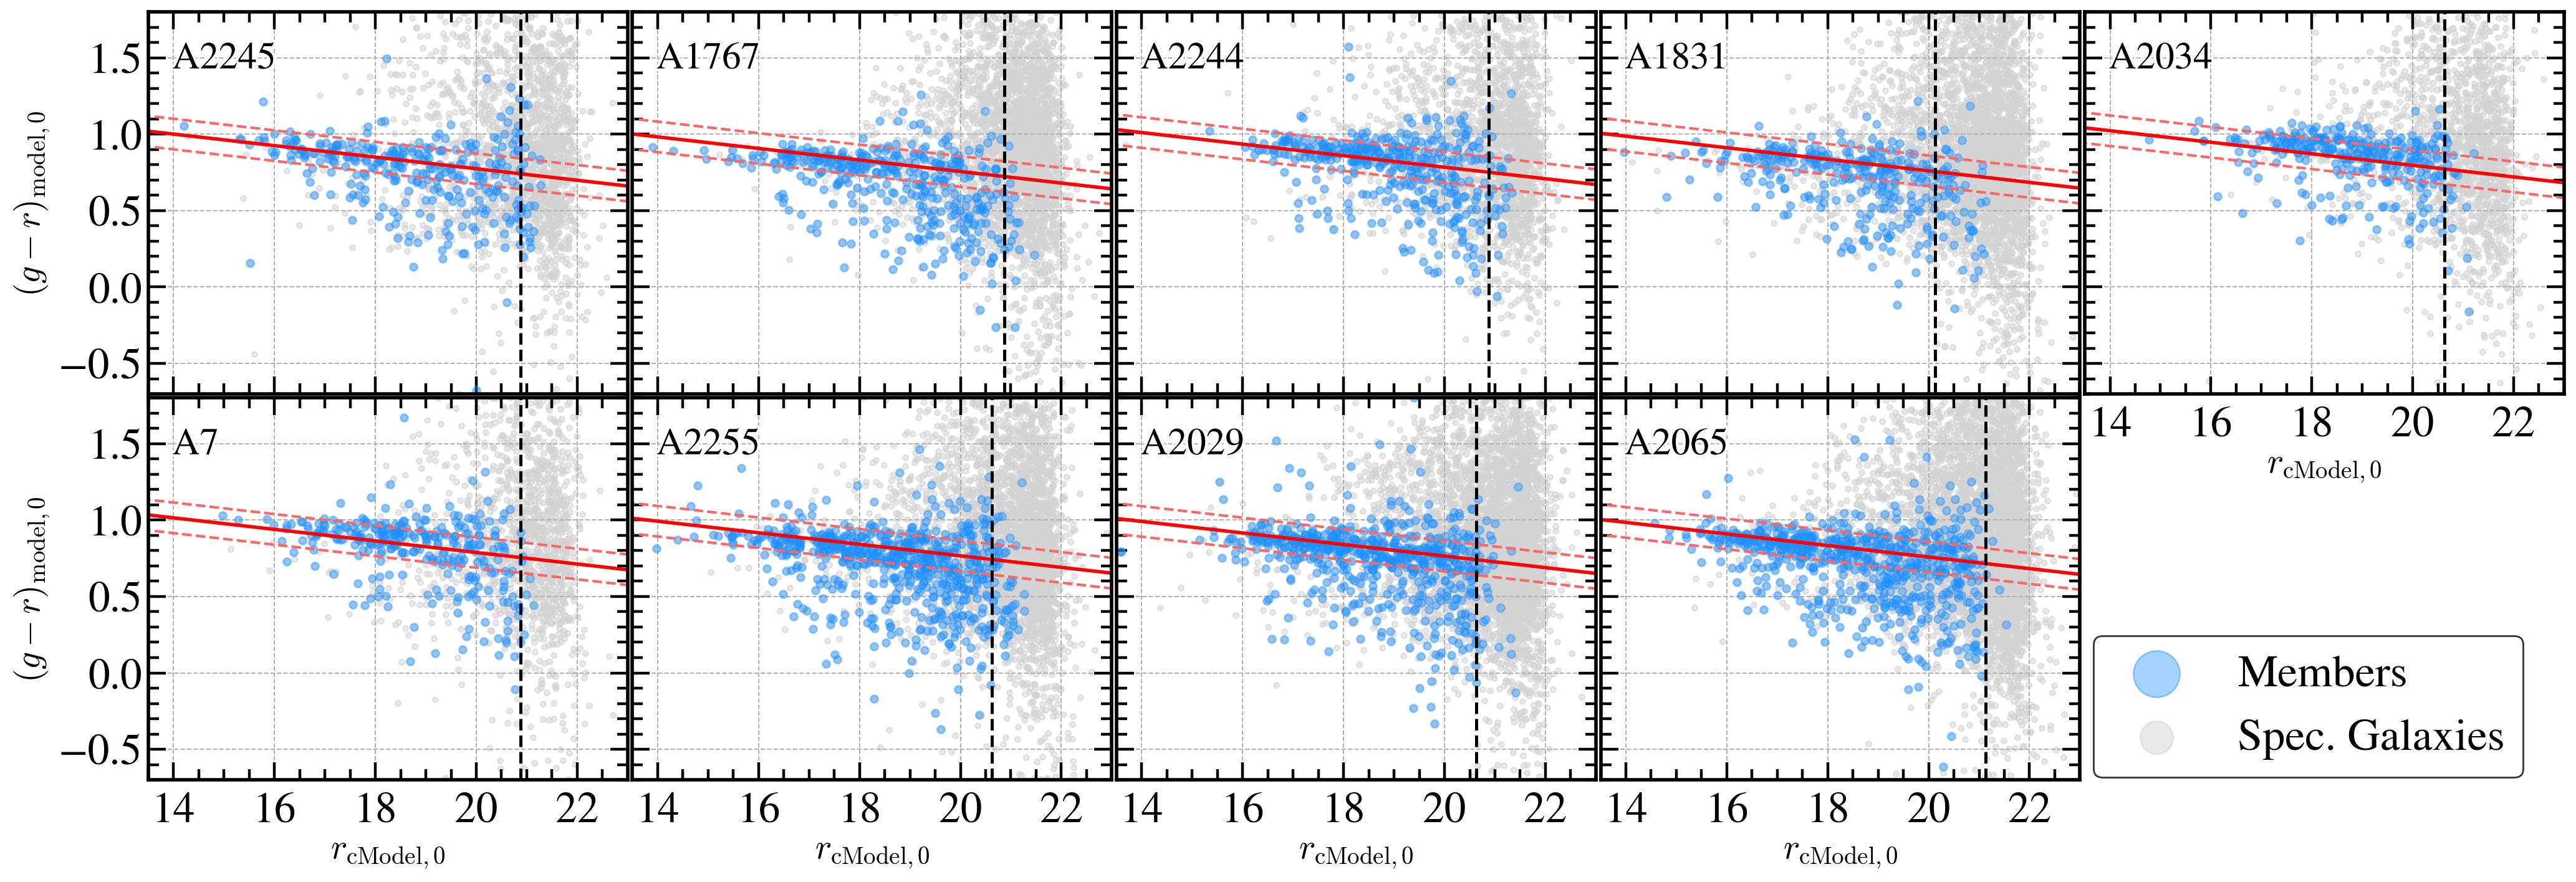

In [9]:
from astropy import units as u
import matplotlib.patheffects as patheffects

# Load spectroscopic completeness magnitude limits for target clusters
Mrlimit = pd.read_csv('../SMF/MACH_1dspec_limit.csv')

# Set up 2x5 panel figure for plotting (adjust for number of clusters)
fig, axes = plt.subplots(
    2, 5, figsize=(25, 8),
    gridspec_kw={'wspace': 0.01, 'hspace': 0.01}
)
axes = axes.flatten()

# Prepare results DataFrame for contamination ratio calculation
ratio_results = pd.DataFrame(
    columns=[
        "TARGET", "Above upper", "Above numerator", "Above denominator",
        "Between lines", "Between numerator", "Between denominator",
        "Below lower", "Below numerator", "Below denominator"
    ]
)

# Loop over each cluster in the MACHLIST to process and plot
for i, TARGET in enumerate(MACHLIST):
    # Get cluster redshift and luminosity distance (for K-corrections, etc)
    z_clid = hecs_vac_data.loc[hecs_vac_data['CLID'] == TARGET, 'Z'].values[0]
    distance_pc = cosmo.luminosity_distance(z_clid).to(u.pc).value

    # Select cluster galaxies within R200 and cluster members
    tdf = df[(df['CLID'] == TARGET) & (df['Rcl/R200'] <= 1.0)]
    tdf_member = tdf[tdf['MEMBER'] == 'Y']

    # Red-sequence line: slope and intercept of the stacked MCMC fit above (in absolute magnitude),
    # evaluated at the apparent magnitude of this cluster
    x_vals = np.linspace(12, 25, 100)
    y_vals = -0.03776430411538441 * (x_vals + 5 - 5 * np.log10(distance_pc)) + 0.09347159270166727

    # Interpolate the y-values from the fit for the data points
    interp_y_vals = np.interp(tdf['cmodelMag_r_0'], x_vals, y_vals)

    # Get r-band spectroscopic completeness limit for the cluster
    speclim = Mrlimit.loc[Mrlimit['TARGET'] == TARGET, 'exceed_bin'].values[0]

    # Compute (g - r) color for all galaxies
    color = tdf['cmodelMag_g_0'] - tdf['cmodelMag_r_0']

    # Mask: limit to galaxies above the spectroscopic completeness magnitude
    x_mask = tdf['cmodelMag_r_0'] < speclim

    # Logical masks for "above upper", "between lines", "below lower" regions (±0.1 mag envelope)
    above_upper   = color > (interp_y_vals + 0.1)
    between_lines = (color <= (interp_y_vals + 0.1)) & (color >= (interp_y_vals - 0.1))
    below_lower   = color < (interp_y_vals - 0.1)

    # Helper function to compute ratios & numbers for each CMD region
    def compute_ratio(region_mask):
        mask = region_mask & x_mask
        # "blue": confirmed members in region & brighter than limiting magnitude
        blue = np.sum(mask & (tdf_member['cmodelMag_r_0'] > -99))
        # "yellow": total spectroscopic galaxies in region & brighter than limit
        yellow = np.sum(mask & (tdf['cmodelMag_r_0'] > -99))
        ratio = blue / yellow if yellow > 0 else 0
        return ratio, blue, yellow

    # Calculate the ratios and numbers for each CMD region
    ratio_above, num_above, den_above = compute_ratio(above_upper)
    ratio_between, num_between, den_between = compute_ratio(between_lines)
    ratio_below, num_below, den_below = compute_ratio(below_lower)

    # Store results in the output DataFrame
    ratio_results.loc[len(ratio_results)] = [
        TARGET,
        ratio_above, num_above, den_above,
        ratio_between, num_between, den_between,
        ratio_below, num_below, den_below
    ]

    # -- PLOT FOR THIS CLUSTER --
    ax = axes[i]

    # Plot cluster members (blue points)
    ax.scatter(
        tdf_member['cmodelMag_r_0'],
        tdf_member['cmodelMag_g_0'] - tdf_member['cmodelMag_r_0'],
        s=20, color='dodgerblue', alpha=0.4, marker='o', label='Members', zorder=2
    )
    # Plot all spectroscopically confirmed galaxies (grey points)
    ax.scatter(
        tdf['cmodelMag_r_0'],
        color,
        s=10, color='lightgray', alpha=0.5, marker='o', label='Spec. Galaxies'
    )

    # Plot main red-sequence fit and ±0.1 mag scatter envelopes
    ax.plot(x_vals, y_vals, color='red', linewidth=2)
    lighter_red = "#FF6666"
    ax.plot(x_vals, y_vals + 0.1, linestyle='--', color=lighter_red, linewidth=1.5)
    ax.plot(x_vals, y_vals - 0.1, linestyle='--', color=lighter_red, linewidth=1.5)

    # Draw a vertical line marking the spectroscopic completeness magnitude
    ax.axvline(x=speclim, color='black', linestyle='--', linewidth=1.8)

    # Annotate cluster name/ID
    ax.text(
        0.05, 0.92, TARGET,
        transform=ax.transAxes,
        fontsize=22, fontweight='normal', ha='left', va='top',
        path_effects=[patheffects.withStroke(linewidth=3, foreground='w')]
    )

    # Set axes limits, ticks, and grid
    ax.set_xlim(13.5, 23)
    ax.set_ylim(-0.7, 1.8)
    ax.set_xticks(np.arange(14, 24, 2))
    ax.set_yticks(np.arange(-0.5, 2.0, 0.5))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))
    ax.grid(which='major', linestyle='--', linewidth=0.7)

    # Style ticks
    ax.tick_params(
        which='both', direction='in',
        top=True, right=True, labeltop=False, labelright=False
    )

    # Y-axis labels for first plot in each row
    if i in [0, 5]:
        ax.set_ylabel(r'$(g - r)_\mathrm{model,0}$', fontsize=20)
    else:
        ax.set_yticklabels([])

    # X-axis labels for bottom row only
    if i >= 4:
        ax.set_xlabel(r'$r_\mathrm{cModel,0}$', fontsize=20)
    else:
        ax.set_xticklabels([])

    # Make plot borders thicker
    for spine in ax.spines.values():
        spine.set_linewidth(2)

# Delete extra (unused) subplots, if there are more axes than clusters
for j in range(len(MACHLIST), len(axes)):
    fig.delaxes(axes[j])

# Get plot legend handles/labels and create a nice figure-level legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.894, 0.09),   # Position the legend in figure coordinates
    loc='lower right',
    ncol=1,
    fontsize=26,
    frameon=True,
    edgecolor='black',
    markerscale=6  # Enlarge marker display in legend
)

# Final figure formatting and export to PDF
plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure5.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [12]:
ratio_results['Between lines'].describe()

count    9.000000
mean     0.566811
std      0.074331
min      0.455108
25%      0.522337
50%      0.603499
75%      0.615079
max      0.672000
Name: Between lines, dtype: float64

In [13]:
ratio_results

,TARGET,Above upper,Above numerator,Above denominator,Between lines,Between numerator,Between denominator,Below lower,Below numerator,Below denominator
0,A2245,0.089552,42,469,0.522337,152,291,0.271978,99,364
1,A1767,0.039098,26,665,0.540299,181,335,0.380410,167,439
2,A2244,0.110708,61,551,0.603499,207,343,0.338462,110,325
3,A1831,0.050265,19,378,0.455108,147,323,0.347003,110,317
4,A2034,0.193798,75,387,0.672000,168,250,0.343195,58,169
5,A7,0.168022,62,369,0.615079,155,252,0.302041,74,245
6,A2255,0.124805,80,641,0.616935,306,496,0.454206,243,535
7,A2029,0.090000,72,800,0.609195,318,522,0.339559,200,589
8,A2065,0.056164,82,1460,0.466847,345,739,0.279689,252,901


In [11]:
# Fraction of members in each CMD region, summed over all clusters
above_ratio = ratio_results['Above numerator'].sum() / ratio_results['Above denominator'].sum()
between_ratio = ratio_results['Between numerator'].sum() / ratio_results['Between denominator'].sum()
below_ratio = ratio_results['Below numerator'].sum() / ratio_results['Below denominator'].sum()

print(f"{above_ratio:.3f}  # Above region: Fraction of members")
print(f"{between_ratio:.3f}  # Between region: Fraction of members")
print(f"{below_ratio:.3f}  # Below region: Fraction of members")

0.091  # Above region: Fraction of members
0.557  # Between region: Fraction of members
0.338  # Below region: Fraction of members
